# BeTiSe — Getting Started

**BeTiSe** (Benchmark Time Series Generator) is a Python library for generating synthetic time series datasets with configurable statistical properties.

This notebook walks you through the three core concepts:

1. **Importing the library**
2. **Generating a base series** — the 15 available process types
3. **Adding features** — trend, seasonality, anomaly, structural break
4. **Combining features** — multiple overlays on a single series
5. **Saving & loading** — write to parquet, read back for ML

---
> **Tip:** Run cells top to bottom. Each section is self-contained.

## 1 · Import the library

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # point to repo root if running from examples/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── BeTiSe public API ────────────────────────────────────────────────────────
from betise import generate_dataframe, run
from betise.config import load_config

print("BeTiSe imported successfully ✓")

BeTiSe imported successfully ✓


In [16]:
# ── Shared plot helper (used throughout the notebook) ────────────────────────
def plot_series(df, title, color="steelblue", ax=None):
    """Plot a single BeTiSe series from a long-format DataFrame."""
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(13, 3.5))
    s = df.sort_values("time")
    ax.plot(s["time"], s["data"], linewidth=1.4, color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time"); ax.set_ylabel("Value")
    ax.grid(alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    if show:
        plt.tight_layout(); plt.show()

---
## 2 · Generating a base series

`load_config()` + `generate_dataframe()` is the core pattern.

| Argument | What it does |
|---|---|
| `base_series` | Which process to generate (see table below) |
| `num_series` | How many independent series |
| `length_range` | `[min, max]` — length drawn uniformly; use `[N, N]` for fixed length |
| `random_seed` | Reproducibility |

### Available base types

| Category | Values |
|---|---|
| **Stationary** | `ar`, `ma`, `arma`, `white_noise` |
| **Stochastic trend** | `random_walk`, `random_walk_drift`, `ari`, `ima`, `arima` |
| **Seasonal** | `sarma`, `sarima` |
| **Volatility** | `arch`, `garch`, `egarch`, `aparch` |

In [3]:
# ── Generate one AR series ────────────────────────────────────────────────────
cfg = load_config(dataset={
    "base_series":  "ar",        # AR(p) process
    "num_series":   1,
    "length_range": [500, 500],  # fixed length = 500
    "random_seed":  42,
})

df, context = generate_dataframe(cfg)

print("DataFrame shape :", df.shape)
print("Columns         :", list(df.columns))
print("\nFirst rows:")
df[["series_id", "time", "data", "primary_category", "sub_category"]].head(8)

DataFrame shape : (500, 68)
Columns         : ['series_id', 'time', 'data', 'length', 'is_stationary', 'primary_category', 'primary_label', 'sub_category', 'sub_label', 'base_series', 'base_process_type', 'order', 'base_coefs', 'trend_type', 'trend_slope', 'trend_intercept', 'trend_coef_a', 'trend_coef_b', 'trend_coef_c', 'trend_damping_rate', 'stochastic_type', 'difference', 'drift_value', 'arima_ar_order', 'arima_ma_order', 'arima_diff', 'is_seasonal', 'seasonality_type', 'seasonality_periods', 'seasonality_amplitudes', 'seasonality_from_base', 'seasonal_difference', 'seasonal_ar_order', 'seasonal_ma_order', 'volatility_type', 'volatility_alpha', 'volatility_beta', 'volatility_omega', 'volatility_theta', 'volatility_lambda', 'volatility_gamma', 'volatility_delta', 'anomaly_type', 'anomaly_count', 'anomaly_indices', 'anomaly_magnitudes', 'break_type', 'break_count', 'break_indices', 'break_magnitudes', 'break_directions', 'trend_shift_change_types', 'location_point', 'location_collect

,series_id,time,data,primary_category,sub_category
0,1,0,-1.850176,trend,linear_trend
1,1,1,-1.764709,trend,linear_trend
2,1,2,-1.681892,trend,linear_trend
3,1,3,-1.609607,trend,linear_trend
4,1,4,-1.837589,trend,linear_trend
5,1,5,-1.659740,trend,linear_trend
6,1,6,-1.695523,trend,linear_trend
7,1,7,-1.662633,trend,linear_trend


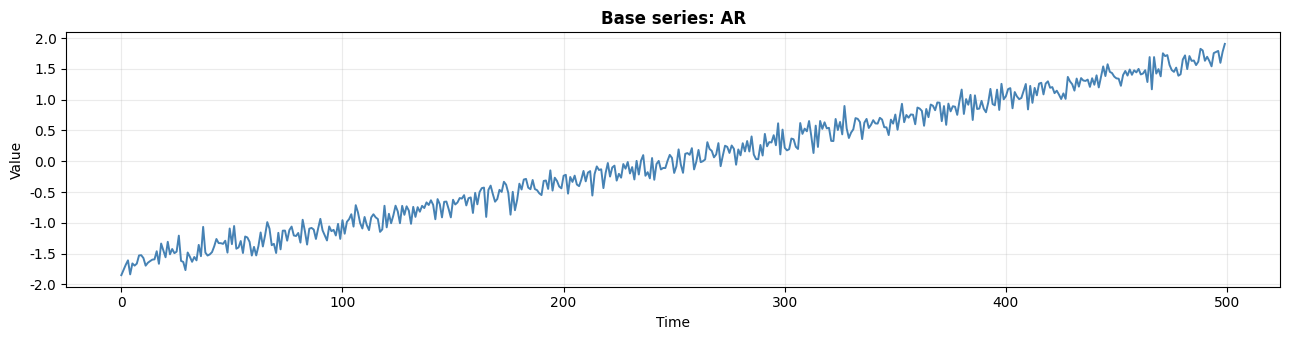

In [4]:
plot_series(df, "Base series: AR")

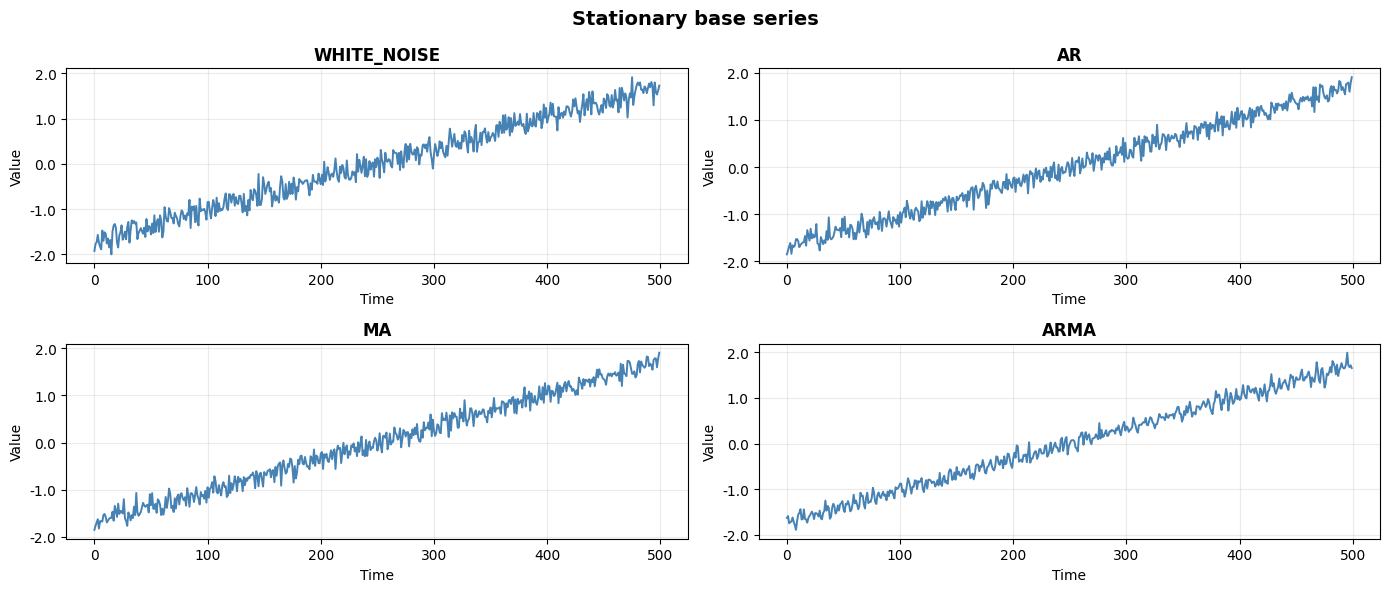

In [5]:
# ── Compare all 4 stationary base types side-by-side ─────────────────────────
stationary_bases = ["white_noise", "ar", "ma", "arma"]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Stationary base series", fontsize=14, fontweight="bold")

for ax, base in zip(axes.flat, stationary_bases):
    cfg = load_config(dataset={
        "base_series": base,
        "num_series":  1,
        "length_range": [500, 500],
        "random_seed": 42,
    })
    d, _ = generate_dataframe(cfg)
    plot_series(d, base.upper(), color="steelblue", ax=ax)

plt.tight_layout()
plt.show()

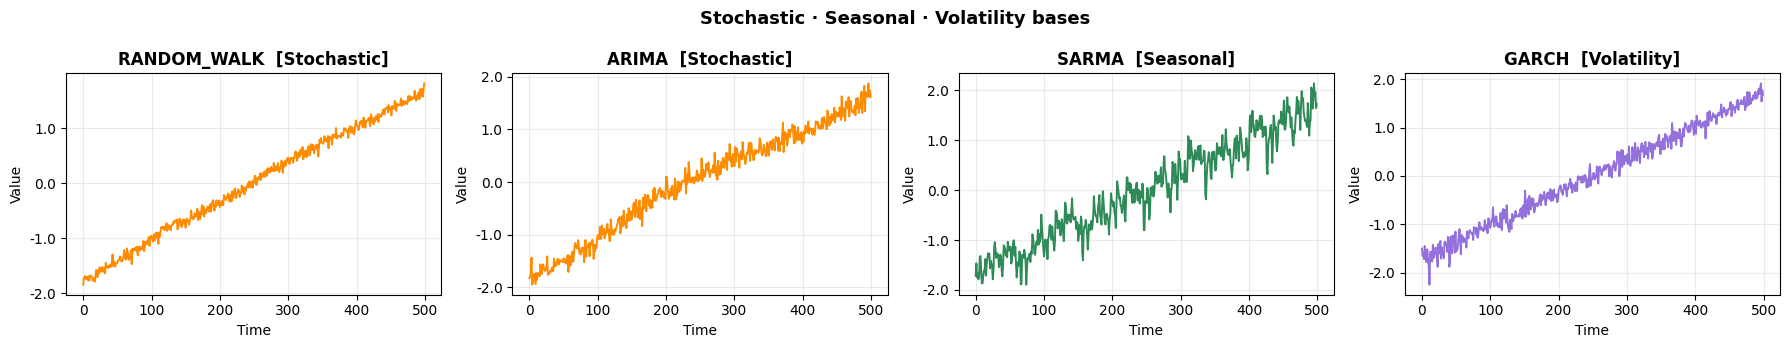

In [6]:
# ── Stochastic, seasonal, volatility bases ───────────────────────────────────
other_bases = [
    ("random_walk",       "Stochastic",  "darkorange"),
    ("arima",             "Stochastic",  "darkorange"),
    ("sarma",             "Seasonal",    "seagreen"),
    ("garch",             "Volatility",  "mediumpurple"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
fig.suptitle("Stochastic · Seasonal · Volatility bases", fontsize=13, fontweight="bold")

for ax, (base, category, color) in zip(axes, other_bases):
    cfg = load_config(dataset={
        "base_series": base,
        "num_series":  1,
        "length_range": [500, 500],
        "random_seed": 7,
    })
    d, _ = generate_dataframe(cfg)
    plot_series(d, f"{base.upper()}  [{category}]", color=color, ax=ax)

plt.tight_layout()
plt.show()

---
## 3 · Adding a feature

Features are enabled inside the `features` dict of the dataset config.  
Set `"enabled": True` for the feature you want — all others default to `False`.

### Available features

| Category | Feature key |
|---|---|
| **Trend** | `linear_trend`, `quadratic_trend`, `cubic_trend`, `exponential_trend` |
| **Seasonality** | `single_seasonality`, `multiple_seasonality` |
| **Anomaly** | `point_anomaly`, `collective_anomaly`, `contextual_anomaly` |
| **Structural break** | `mean_shift`, `variance_shift`, `trend_shift` |

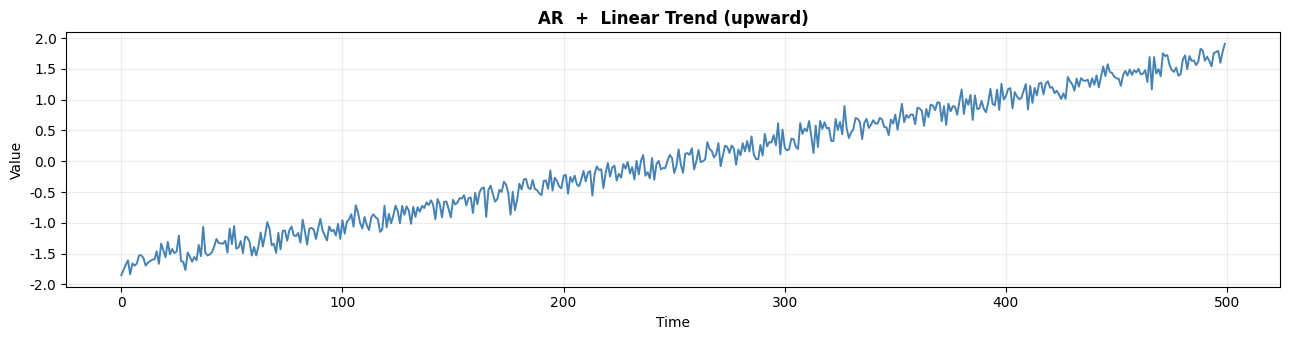

In [7]:
# ── AR + linear trend (upward) ────────────────────────────────────────────────
cfg = load_config(dataset={
    "base_series":  "ar",
    "num_series":   1,
    "length_range": [500, 500],
    "random_seed":  42,
    "features": {
        "linear_trend": {"enabled": True, "direction": "upward"},
    },
})

df_trend, _ = generate_dataframe(cfg)
plot_series(df_trend, "AR  +  Linear Trend (upward)")

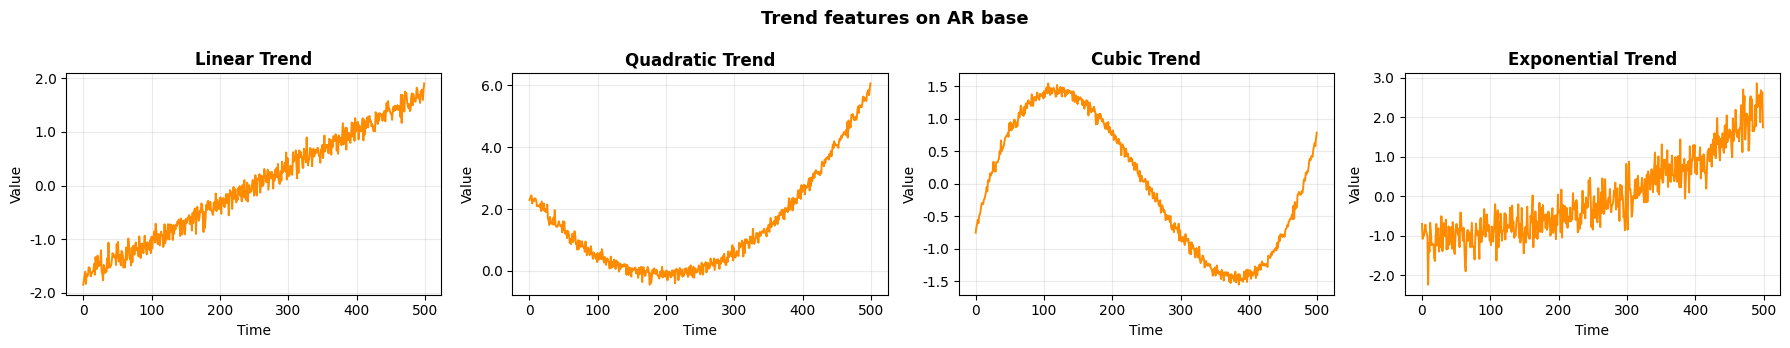

In [8]:
# ── All 4 trend types on AR base ─────────────────────────────────────────────
trend_features = [
    ("linear_trend",      {"direction": "upward"}),
    ("quadratic_trend",   {}),
    ("cubic_trend",       {}),
    ("exponential_trend", {"direction": "upward"}),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
fig.suptitle("Trend features on AR base", fontsize=13, fontweight="bold")

for ax, (feat, extra) in zip(axes, trend_features):
    cfg = load_config(dataset={
        "base_series": "ar", "num_series": 1,
        "length_range": [500, 500], "random_seed": 42,
        "features": {feat: {"enabled": True, **extra}},
    })
    d, _ = generate_dataframe(cfg)
    plot_series(d, feat.replace("_", " ").title(), color="darkorange", ax=ax)

plt.tight_layout(); plt.show()

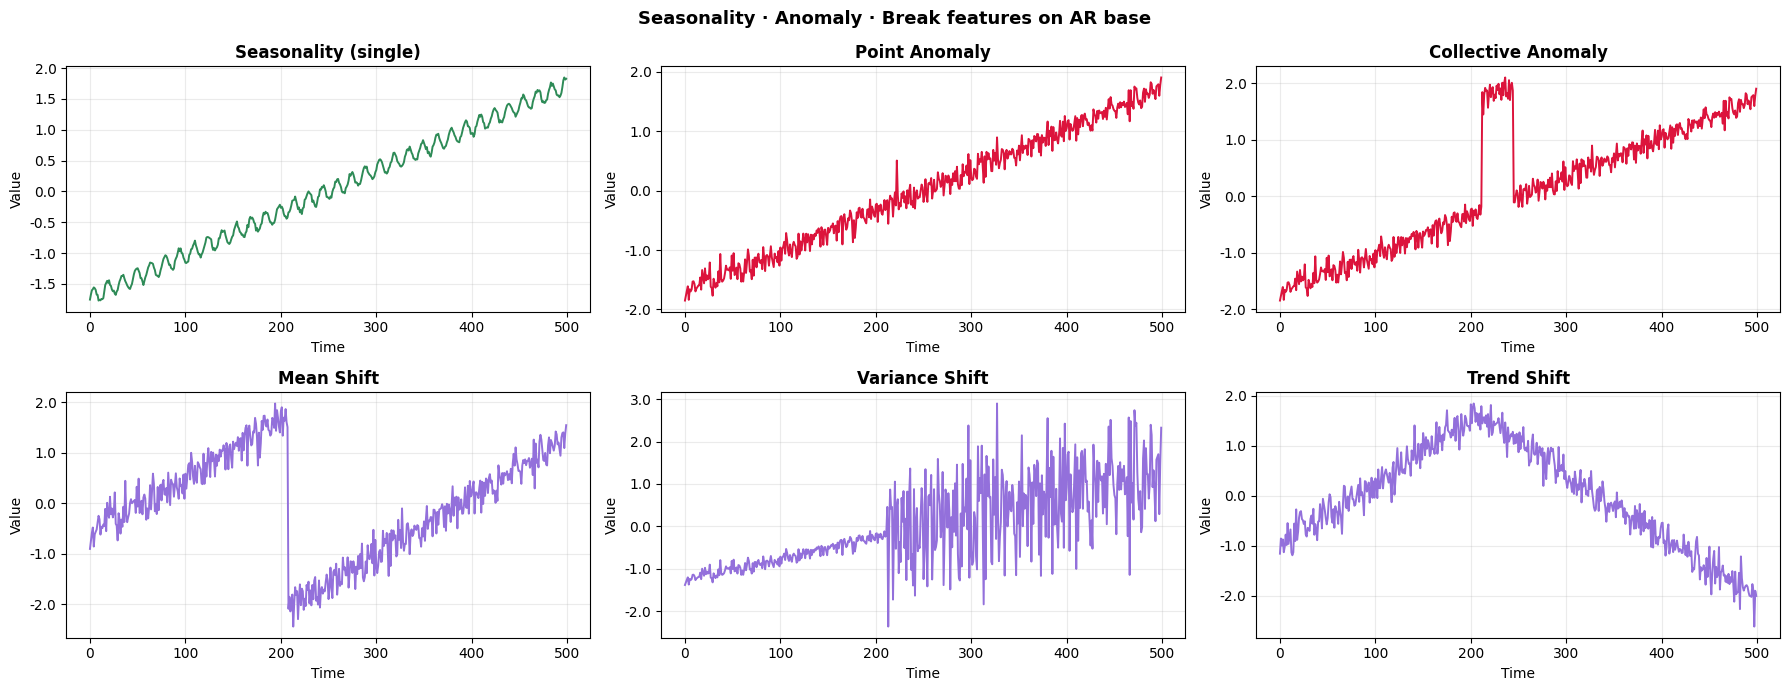

In [19]:
# ── Anomaly & break features ──────────────────────────────────────────────────
other_features = [
    ("single_seasonality",  {},                         "seagreen",     "Seasonality (single)"),
    ("point_anomaly",       {"is_spike": False, "scale_factor": 0.3},         "crimson",      "Point Anomaly"),
    ("collective_anomaly",  {},                         "crimson",      "Collective Anomaly"),
    ("mean_shift",          {},                         "mediumpurple", "Mean Shift"),
    ("variance_shift",      {},                         "mediumpurple", "Variance Shift"),
    ("trend_shift",         {},                         "mediumpurple", "Trend Shift"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
fig.suptitle("Seasonality · Anomaly · Break features on AR base", fontsize=13, fontweight="bold")

for ax, (feat, extra, color, label) in zip(axes.flat, other_features):
    cfg = load_config(dataset={
        "base_series": "ar", "num_series": 1,
        "length_range": [500, 500], "random_seed": 42,
        "features": {feat: {"enabled": True, **extra}},
    })
    d, _ = generate_dataframe(cfg)
    plot_series(d, label, color=color, ax=ax)

plt.tight_layout(); plt.show()

---
## 4 · Combining features

Multiple features can be active at the same time — just set `"enabled": True` for each one.  
BeTiSe applies them sequentially on top of the base series.

> **Example:** trend + seasonality + anomaly all on one AR series.

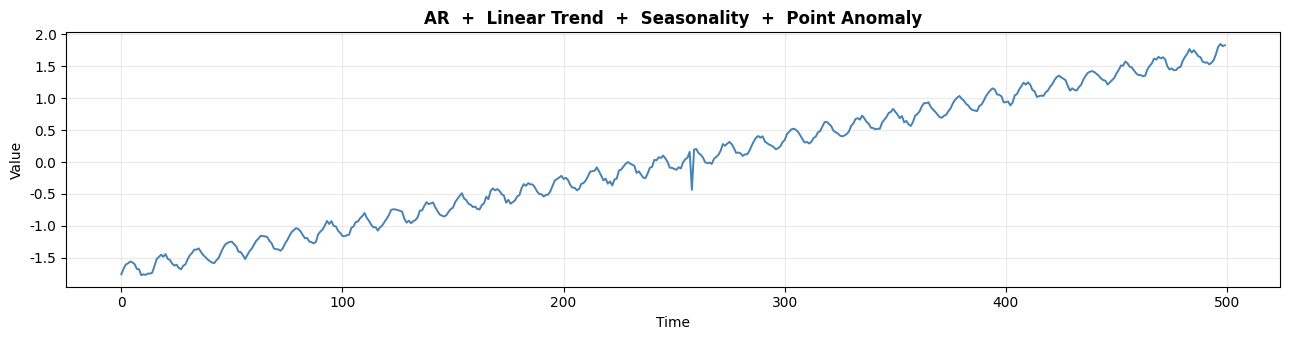

In [21]:
# ── AR  +  linear trend  +  single seasonality  +  point anomaly ──────────────
cfg = load_config(dataset={
    "base_series":  "ar",
    "num_series":   1,
    "length_range": [500, 500],
    "random_seed":  42,
    "features": {
        "linear_trend":       {"enabled": True, "direction": "upward"},
        "single_seasonality": {"enabled": True},
        "point_anomaly":      {"enabled": True, "is_spike": True, "scale_factor": 0.2},
    },
})

df_combo, _ = generate_dataframe(cfg)
plot_series(df_combo, "AR  +  Linear Trend  +  Seasonality  +  Point Anomaly", color="steelblue")

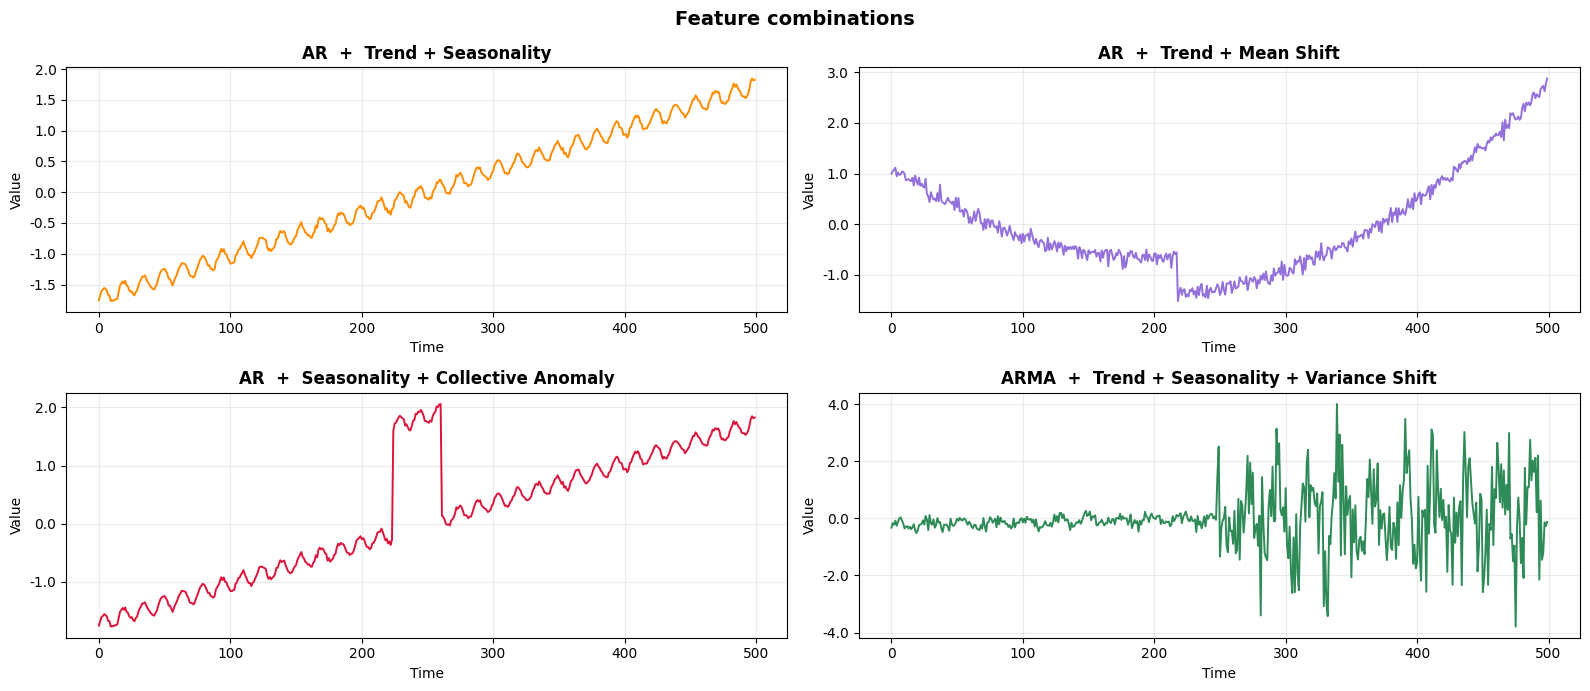

In [11]:
# ── Four different combination recipes side-by-side ───────────────────────────
combos = [
    (
        "Trend + Seasonality",
        "ar",
        {"linear_trend": {"enabled": True, "direction": "upward"},
         "single_seasonality": {"enabled": True}},
        "darkorange",
    ),
    (
        "Trend + Mean Shift",
        "ar",
        {"quadratic_trend": {"enabled": True},
         "mean_shift":       {"enabled": True}},
        "mediumpurple",
    ),
    (
        "Seasonality + Collective Anomaly",
        "ar",
        {"single_seasonality": {"enabled": True},
         "collective_anomaly": {"enabled": True}},
        "crimson",
    ),
    (
        "Trend + Seasonality + Variance Shift",
        "arma",
        {"linear_trend":       {"enabled": True, "direction": "downward"},
         "single_seasonality": {"enabled": True},
         "variance_shift":     {"enabled": True}},
        "seagreen",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
fig.suptitle("Feature combinations", fontsize=14, fontweight="bold")

for ax, (title, base, feats, color) in zip(axes.flat, combos):
    cfg = load_config(dataset={
        "base_series":  base,
        "num_series":   1,
        "length_range": [500, 500],
        "random_seed":  42,
        "features":     feats,
    })
    d, _ = generate_dataframe(cfg)
    plot_series(d, f"{base.upper()}  +  {title}", color=color, ax=ax)

plt.tight_layout()
plt.show()

---
## 5 · Saving & loading

Use `run()` instead of `generate_dataframe()` when you want to **write to disk**.  
The output is a `.parquet` file — efficient for large datasets.

| Parameter | Purpose |
|---|---|
| `output_dir` | Directory to write the file (created automatically) |
| `output_name` | File name (must end in `.parquet`) |

After writing, load with `pandas.read_parquet()` for tabular use, or convert to a numpy array for ML.

In [12]:
# ── Save 5 AR series with a linear trend to parquet ──────────────────────────
OUT_DIR  = "intro_output"
OUT_FILE = "ar_linear_trend.parquet"

cfg = load_config(dataset={
    "base_series":  "ar",
    "num_series":   5,
    "length_range": [300, 500],
    "random_seed":  42,
    "output_dir":   OUT_DIR,
    "output_name":  OUT_FILE,
    "features": {
        "linear_trend": {"enabled": True, "direction": "upward"},
    },
})

run(cfg)
print(f"Saved → {OUT_DIR}/{OUT_FILE}")

DATASET GENERATION COMPLETE
Output   : /Users/iguzel/Desktop/ts-generator-gsd/examples/intro_output/ar_linear_trend.parquet
Series   : 5
Base     : ar
Features : ['linear_trend']
Saved → intro_output/ar_linear_trend.parquet


In [13]:
# ── Load back with pandas ─────────────────────────────────────────────────────
df_loaded = pd.read_parquet(f"{OUT_DIR}/{OUT_FILE}")

print("Shape            :", df_loaded.shape)
print("Series IDs       :", df_loaded["series_id"].unique().tolist())
print("Lengths per series:")
print(df_loaded.groupby("series_id")["time"].count().rename("length").to_string())
print("\nSample rows:")
df_loaded[["series_id", "time", "data", "primary_category", "sub_category"]].head(6)

Shape            : (1940, 68)
Series IDs       : [1, 2, 3, 4, 5]
Lengths per series:
series_id
1    402
2    301
3    364
4    374
5    499

Sample rows:


,series_id,time,data,primary_category,sub_category
0,1,0,-1.682805,trend,linear_trend
1,1,1,-1.074532,trend,linear_trend
2,1,2,-1.558274,trend,linear_trend
3,1,3,-1.328139,trend,linear_trend
4,1,4,-1.270974,trend,linear_trend
5,1,5,-1.991722,trend,linear_trend


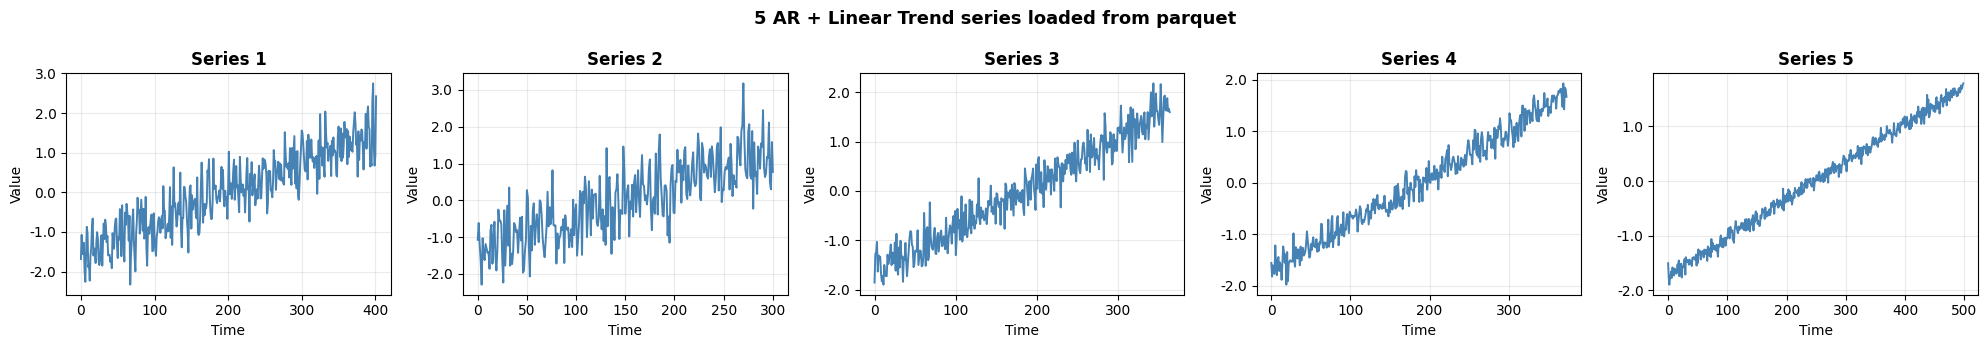

In [14]:
# ── Plot all 5 loaded series ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
fig.suptitle("5 AR + Linear Trend series loaded from parquet", fontsize=13, fontweight="bold")

for ax, sid in zip(axes, sorted(df_loaded["series_id"].unique())):
    subset = df_loaded[df_loaded["series_id"] == sid]
    plot_series(subset, f"Series {sid}", color="steelblue", ax=ax)

plt.tight_layout()
plt.show()

In [15]:
# ── Convert to numpy arrays (one array per series) ────────────────────────────
arrays = {
    sid: df_loaded[df_loaded["series_id"] == sid]
              .sort_values("time")["data"]
              .to_numpy()
    for sid in sorted(df_loaded["series_id"].unique())
}

for sid, arr in arrays.items():
    print(f"  series_id={sid}  shape={arr.shape}  dtype={arr.dtype}")

print("\nNumpy arrays are ready for scikit-learn, PyTorch, etc.")

  series_id=1  shape=(402,)  dtype=float64
  series_id=2  shape=(301,)  dtype=float64
  series_id=3  shape=(364,)  dtype=float64
  series_id=4  shape=(374,)  dtype=float64
  series_id=5  shape=(499,)  dtype=float64

Numpy arrays are ready for scikit-learn, PyTorch, etc.


---
## Next steps

| Script | What it does |
|---|---|
| `examples/01_quickstart.py` | In-memory generation, save to disk, feature combinations |
| `examples/02_benchmark_dataset.py` | All base types × 3 length buckets |
| `examples/03_feature_suite.py` | All base types × all features |
| `examples/05_classification_dataset.py` | Balanced 7-class ML dataset (14,000 series) |
| `examples/07_feature_gallery.py` | PDF: all 15 base types + all 12 features |
| `examples/08_combinations_gallery.py` | PDF: all 573 valid base × feature combinations |

See **[USAGE.md](../USAGE.md)** for the full configuration reference.